# Allosteric geometry analysis

Analyses `data/allosteric_nets/geometry_{0..4}/task_{0..4}/realization_{0..4}`.

**Steps:**
1. Load trained allosteric networks.
2. Equilibrate using the allosteric actuation protocol (JAX-based, same `crf` FIRE solver as the auxetic pipeline).
3. Compute generalised susceptibilities at both subtask strains (input 0.5 and 1.0).
4. Compute leading cost-Hessian eigenvector ψ (cached per realization).
5. Reproduce all plots from `tofelipe0421_analysis.ipynb`.
6. Compute 8×8 Pearson/Spearman feature-correlation matrices (Analysis-9 style).
7. Per-geometry and grand averages.

In [9]:
# ── Paths ─────────────────────────────────────────────────────────────────────
import sys, os
from pathlib import Path

REPO_ROOT = Path('../../').resolve()
sys.path.insert(0, str(REPO_ROOT / 'src'))

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from collections import defaultdict
from scipy.stats import rankdata as _rd, spearmanr as _spearmanr
from scipy.sparse.linalg import LinearOperator, eigsh
import warnings

import jax
import jax.numpy as jnp
jax.config.update('jax_enable_x64', True)

from generalized_susceptibility import (
    compute_constrained_hessian_inverse,
    compute_full_jacobian_matrixwise,
    susceptibilities_from_jacobian,
)
from training_functions_with_toggle import crf as _crf

print('JAX devices:', jax.devices())

JAX devices: [CpuDevice(id=0)]


In [10]:
# ── Config ─────────────────────────────────────────────────────────────────────
DATA_DIR        = REPO_ROOT / 'data' / 'allosteric_nets'
FIGURE_DIR      = REPO_ROOT / 'data' / 'figure_data'
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

GEOMETRIES    = list(range(5))
N_TASKS       = 5
N_REALIZATIONS = 5

RECOMPUTE_HESSIAN = False   # set True to force recompute cost_hessian_eigs.npz
N_EQUIL_STEPS     = 20     # quasistatic steps for equilibration (fewer = faster)
K_EIGS            = 5      # Lanczos eigenvectors
HVP_EPSILON       = 1e-4
N_BINS            = 60
THRESHOLDS        = np.linspace(0, 95, 40)
MIN_SUCCESS_RATIO = 0.1    # max(min_loss/init_loss) to consider a run successful

SUBTASK_STRAINS = [1.0, 0.5]  # strain_input for subtask1 (MSE1) and subtask2 (MSE2)

## Helper functions

In [11]:
def incmat_to_edges(incidence_matrix):
    """Convert (E, N) incidence matrix to (E, 2) edge array.

    Convention: edges[e] = [i, j] where B[e, i] = +1, B[e, j] = -1.
    Compatible with elastic_energy in training_functions_with_toggle.py.
    """
    E = incidence_matrix.shape[0]
    edges = np.zeros((E, 2), dtype=int)
    for e in range(E):
        row = incidence_matrix[e]
        edges[e, 0] = int(np.where(row > 0)[0][0])
        edges[e, 1] = int(np.where(row < 0)[0][0])
    return edges


def _find_fallback_geometry_files(data_dir, gid, exclude_path):
    """Search other realizations in geometry_{gid} for valid nodes/incmat/eq_lens.

    All realizations on the same geometry share these files, so any valid
    sibling realization can serve as a fallback for a corrupted one.
    Returns (nodes, incmat, eq_lens) or None if nothing found.
    """
    geom_dir = data_dir / f'geometry_{gid}'
    for task_dir in sorted(geom_dir.iterdir()):
        if not task_dir.is_dir():
            continue
        for real_dir in sorted(task_dir.iterdir()):
            if not real_dir.is_dir() or real_dir == exclude_path:
                continue
            try:
                nodes  = np.load(real_dir / 'nodes.npy')
                incmat = np.load(real_dir / 'incidence_matrix.npy')
                eq_len = np.load(real_dir / 'eq_lengths.npy')
                return nodes, incmat, eq_len
            except Exception:
                continue
    return None


def load_realization(gid, tid, rid):
    """Load one allosteric realization. Returns dict or None if missing files."""
    path = DATA_DIR / f'geometry_{gid}' / f'task_{tid}' / f'realization_{rid}'
    required = ['nodes.npy', 'incidence_matrix.npy', 'eq_lengths.npy',
                'stiffnesses.npy', 'mse1.npy', 'mse2.npy', 'tasks.txt']
    if not all((path / f).exists() for f in required):
        return None

    # Geometry files are shared across realizations on the same geometry;
    # fall back to a sibling realization if any of them are corrupted.
    try:
        nodes   = np.load(path / 'nodes.npy')
        incmat  = np.load(path / 'incidence_matrix.npy')
        eq_lens = np.load(path / 'eq_lengths.npy')
    except Exception as exc:
        print(f'    Warning: geometry files corrupted at {path} ({exc}), trying fallback…')
        fallback = _find_fallback_geometry_files(DATA_DIR, gid, path)
        if fallback is None:
            print(f'    No fallback found for geometry_{gid}, skipping.')
            return None
        nodes, incmat, eq_lens = fallback

    stiff    = np.load(path / 'stiffnesses.npy')
    mse1     = np.load(path / 'mse1.npy')
    mse2     = np.load(path / 'mse2.npy')
    task_arr = np.loadtxt(path / 'tasks.txt')  # [geom_seed, strain_out2, strain_out]
    edges    = incmat_to_edges(incmat)
    return dict(
        path=path, nodes=nodes, incmat=incmat, edges=edges,
        eq_lengths=eq_lens, stiffnesses=stiff,
        mse1=mse1, mse2=mse2,
        geometry_seed=float(task_arr[0]),
        strain_output2=float(task_arr[1]),   # target at input_strain=0.5
        strain_output=float(task_arr[2]),    # target at input_strain=1.0
    )


def is_successful(d, threshold=MIN_SUCCESS_RATIO):
    """True if training converged (loss decreased by 1/threshold relative)."""
    combined = (d['mse1'] + d['mse2']) / 2.0
    if combined[0] == 0:
        return False
    return (combined.min() / combined[0]) < threshold

In [12]:
# ── JAX-based allosteric equilibration ────────────────────────────────────────

def compute_allosteric_equilibrium(
    stiffnesses, edges, eq_lengths, nodes0, strain_input, n_steps=N_EQUIL_STEPS
):
    """
    Quasistatic allosteric equilibration in JAX (differentiable through crf).

    Node 0 (in_node_1) is fixed.  Node 1 (in_node_2) is moved along +x by
    strain_input × d_input_initial.  Free nodes are equilibrated at each step.

    Returns equilibrium positions as (N, 2) array.
    """
    pos_flat = jnp.asarray(nodes0.flatten())
    edges_j  = jnp.asarray(edges, dtype=jnp.int32)
    eq_j     = jnp.asarray(eq_lengths)
    k_j      = jnp.asarray(stiffnesses)

    x0, y0 = nodes0[0]
    x1_init, y1_init = nodes0[1]
    d0       = float(np.linalg.norm(nodes0[1] - nodes0[0]))
    total_dx = strain_input * d0

    # DOF layout (2D): node i occupies DOFs [2i, 2i+1]
    # source_nodes_dof ordering follows compute_quasistatic_trajectory_auxetic_jax:
    #   [all x-DOFs of constrained nodes, then all y-DOFs]
    # For constrained nodes [0, 1]: source_nodes_dof = [0, 2, 1, 3]
    source_dof = jnp.array([0, 2, 1, 3], dtype=jnp.int32)  # [x0, x1, y0, y1]

    current_pos = pos_flat
    for step in range(n_steps):
        frac     = (step + 1) / n_steps
        x1_new   = x1_init + frac * total_dx
        # imposed = [x-DOFs of nodes 0,1 , y-DOFs of nodes 0,1]
        imposed  = jnp.array([x0, x1_new, y0, y1_init])
        current_pos = _crf(k_j, edges_j, eq_j, current_pos, source_dof, imposed)

    return jnp.reshape(current_pos, (-1, 2))  # (N, 2)


def compute_susceptibilities_at_strain(stiffnesses, edges, eq_lengths, nodes0, strain_input):
    """Susceptibilities (s_par, s_perp, s_eq, s_tot) at the equilibrium under strain_input.

    Input nodes (0 and 1) are treated as constrained for the susceptibility computation.
    """
    eq_pos = np.array(compute_allosteric_equilibrium(
        stiffnesses, edges, eq_lengths, nodes0, strain_input
    ))
    H_full_inv = compute_constrained_hessian_inverse(
        positions=eq_pos,
        edges=edges,
        stiffnesses=stiffnesses,
        rest_lengths=eq_lengths,
        constrained_nodes=[0, 1],  # input nodes
    )
    _, Hjac_parts, geom = compute_full_jacobian_matrixwise(
        positions=eq_pos,
        edges=edges,
        stiffnesses=stiffnesses,
        rest_lengths=eq_lengths,
        H_ff_inv=None,
        H_full_inv=H_full_inv,
    )
    s_par, s_perp, s_eq, s_tot = susceptibilities_from_jacobian(Hjac_parts)
    _, fs_k, ells, nhats, _ = geom
    edge_strain = (ells - eq_lengths) / np.maximum(eq_lengths, 1e-12)
    edge_stress = fs_k  # k*(1 - L0/ell) = k*strain*ell/ell_0 ≈ stress
    return (
        np.asarray(s_par,  dtype=float),
        np.asarray(s_perp, dtype=float),
        np.asarray(s_eq,   dtype=float),
        np.asarray(s_tot,  dtype=float),
        np.asarray(edge_strain, dtype=float),
        np.asarray(edge_stress, dtype=float),
        np.asarray(ells,   dtype=float),
    )

In [13]:
# ── Cost Hessian eigenvector (allosteric loss) ─────────────────────────────────

def compute_allosteric_cost_hessian_evec(
    stiffnesses, edges, eq_lengths, nodes0,
    strain_input, d_target,
    n_steps=N_EQUIL_STEPS, k_eigs=K_EIGS, hvp_epsilon=HVP_EPSILON,
):
    """
    Leading eigenvector of d^2 L / dk_i dk_j  where  L = (d_out(k) - d_target)^2.

    Uses JAX autodiff through the JAX-based FIRE equilibration (custom_vjp).
    Lanczos via scipy.sparse.linalg.eigsh with matrix-free HVPs.

    Returns |eigvec| of shape (n_edges,).
    """
    n_edges  = len(stiffnesses)
    base_k   = np.array(stiffnesses, dtype=float)
    edges_j  = jnp.asarray(edges,       dtype=jnp.int32)
    eq_j     = jnp.asarray(eq_lengths)
    nodes_j  = jnp.asarray(nodes0)

    x0, y0       = nodes0[0]
    x1_init, y1_init = nodes0[1]
    d0       = float(np.linalg.norm(nodes0[1] - nodes0[0]))
    total_dx = strain_input * d0
    source_dof = jnp.array([0, 2, 1, 3], dtype=jnp.int32)

    def _output_dist_jax(k_jax):
        pos_flat = nodes_j.flatten()
        for step in range(n_steps):
            frac    = (step + 1) / n_steps
            x1_new  = x1_init + frac * total_dx
            imposed = jnp.array([x0, x1_new, y0, y1_init])
            pos_flat = _crf(k_jax, edges_j, eq_j, pos_flat, source_dof, imposed)
        pos_2d = jnp.reshape(pos_flat, (-1, 2))
        return jnp.linalg.norm(pos_2d[3] - pos_2d[2])  # ||out_node_2 - out_node_1||

    def loss_jax(k_jax):
        d_out = _output_dist_jax(k_jax)
        return (d_out - d_target) ** 2

    grad_loss = jax.jit(jax.grad(loss_jax))

    def jax_gradient(k):
        return np.array(grad_loss(jnp.asarray(k, dtype=jnp.float64)))

    print(f'      Computing base gradient ({n_edges} edges, {n_steps} steps) ...', flush=True)
    g0 = jax_gradient(base_k)

    def hvp(v):
        v    = np.asarray(v, dtype=float)
        norm_v = np.linalg.norm(v)
        if norm_v < 1e-14:
            return np.zeros_like(v)
        g_fwd = jax_gradient(base_k + hvp_epsilon * v / norm_v)
        return norm_v * (g_fwd - g0) / hvp_epsilon

    H_op = LinearOperator((n_edges, n_edges), matvec=hvp, dtype=float)
    k    = min(k_eigs, n_edges - 1)
    print(f'      Starting eigsh (k={k}) ...', flush=True)
    eigenvalues, eigenvectors = eigsh(H_op, k=k, which='LM')
    order = np.argsort(eigenvalues)
    return np.abs(eigenvectors[:, order[-1]])  # leading eigenvec, (n_edges,)

In [14]:
def load_or_compute_hessian_evecs(d, recompute=RECOMPUTE_HESSIAN):
    """Load cached cost_hessian_eigs.npz or compute and save it.

    Returns list of two arrays (one per subtask): each (n_edges,) |leading eigvec|.
    """
    cache_path = d['path'] / 'cost_hessian_eigs.npz'
    if cache_path.exists() and not recompute:
        npz = np.load(cache_path)
        return [npz['evec_subtask1'], npz['evec_subtask2']]

    nodes      = d['nodes']
    edges      = d['edges']
    eq_lengths = d['eq_lengths']
    stiff      = d['stiffnesses']

    d0_out    = float(np.linalg.norm(nodes[3] - nodes[2]))
    d_target1 = (1 + d['strain_output'])  * d0_out  # subtask1: input=1.0
    d_target2 = (1 + d['strain_output2']) * d0_out  # subtask2: input=0.5

    evecs = []
    for subtask_idx, (strain_in, d_tgt) in enumerate([
        (1.0, d_target1), (0.5, d_target2)
    ]):
        print(f'    Subtask {subtask_idx+1}: strain_input={strain_in}, d_target={d_tgt:.4f}')
        psi = compute_allosteric_cost_hessian_evec(
            stiff, edges, eq_lengths, nodes,
            strain_in, d_tgt,
        )
        evecs.append(psi)

    np.savez(
        cache_path,
        evec_subtask1   = evecs[0],
        evec_subtask2   = evecs[1],
        strain_inputs   = np.array([1.0, 0.5]),
        d_targets       = np.array([d_target1, d_target2]),
    )
    print(f'    Saved → {cache_path}')
    return evecs

## Main computation loop

In [16]:
# all_results[gid][tid][rid] = result dict or None
all_results = {}

total = len(GEOMETRIES) * N_TASKS * N_REALIZATIONS
done = 0
skipped = 0

for gid in GEOMETRIES:
    all_results[gid] = {}
    for tid in range(N_TASKS):
        all_results[gid][tid] = {}
        for rid in range(N_REALIZATIONS):
            try:
                d = load_realization(gid, tid, rid)
            except:
                continue



            if d is None or not is_successful(d):
                all_results[gid][tid][rid] = None
                skipped += 1
                done += 1
                continue

            print(f'  g{gid}/t{tid}/r{rid} — {len(d["edges"])} edges', flush=True)

            # ── Cost Hessian eigenvectors (cached) ────────────────────────────
            evecs = load_or_compute_hessian_evecs(d)

            # ── Susceptibilities at both subtask strains ───────────────────────
            subtask_data = []
            for subtask_idx, strain_in in enumerate(SUBTASK_STRAINS):
                (
                    s_par, s_perp, s_eq, s_tot,
                    edge_strain, edge_stress, ells
                ) = compute_susceptibilities_at_strain(
                    d['stiffnesses'], d['edges'], d['eq_lengths'],
                    d['nodes'], strain_in,
                )
                subtask_data.append(dict(
                    strain_input  = strain_in,
                    s_par         = s_par,
                    s_perp        = s_perp,
                    s_eq          = s_eq,
                    s_tot         = s_tot,
                    stiffness     = d['stiffnesses'],
                    edge_strain   = edge_strain,
                    edge_stress   = edge_stress,
                    psi           = evecs[subtask_idx],  # |leading cost Hessian evec|
                ))

            d['subtask_data'] = subtask_data
            all_results[gid][tid][rid] = d
            done += 1

print(f'\nDone: {done}/{total}  (skipped {skipped} unsuccessful or missing)')

  g0/t0/r0 — 260 edges
  g0/t0/r1 — 260 edges
  g0/t0/r2 — 260 edges
  g0/t0/r3 — 260 edges
  g0/t0/r4 — 260 edges
  g0/t1/r0 — 260 edges
  g0/t1/r1 — 260 edges
  g0/t1/r2 — 260 edges
  g0/t1/r3 — 260 edges
  g0/t1/r4 — 260 edges
  g0/t2/r0 — 260 edges
  g0/t2/r1 — 260 edges
  g0/t2/r2 — 260 edges
  g0/t2/r3 — 260 edges
  g0/t2/r4 — 260 edges
  g0/t3/r0 — 260 edges
  g0/t3/r1 — 260 edges
  g0/t3/r2 — 260 edges
  g0/t3/r3 — 260 edges
  g0/t3/r4 — 260 edges
  g0/t4/r0 — 260 edges
  g0/t4/r1 — 260 edges
  g0/t4/r2 — 260 edges
  g0/t4/r3 — 260 edges
  g0/t4/r4 — 260 edges
  g1/t0/r0 — 259 edges
  g1/t0/r1 — 259 edges
  g1/t0/r3 — 259 edges
    Subtask 1: strain_input=1.0, d_target=0.9951
      Computing base gradient (259 edges, 20 steps) ...
      Starting eigsh (k=5) ...
    Subtask 2: strain_input=0.5, d_target=0.0000
      Computing base gradient (259 edges, 20 steps) ...
      Starting eigsh (k=5) ...
    Saved → /Users/felipe/Library/CloudStorage/Box-Box/PhD/nonlinear_mech_nets/data/

/var/folders/jf/_tvrzlnx2ls96g0c99c63mjm0000gn/T/ipykernel_64190/2020567224.py:65: UserWarning: loadtxt: input contained no data: "/Users/felipe/Library/CloudStorage/Box-Box/PhD/nonlinear_mech_nets/data/allosteric_nets/geometry_2/task_1/realization_1/tasks.txt"
  task_arr = np.loadtxt(path / 'tasks.txt')  # [geom_seed, strain_out2, strain_out]


      Starting eigsh (k=5) ...
    Subtask 2: strain_input=0.5, d_target=0.5065
      Computing base gradient (265 edges, 20 steps) ...
      Starting eigsh (k=5) ...
    Saved → /Users/felipe/Library/CloudStorage/Box-Box/PhD/nonlinear_mech_nets/data/allosteric_nets/geometry_2/task_1/realization_2/cost_hessian_eigs.npz
  g2/t1/r3 — 265 edges
    Subtask 1: strain_input=1.0, d_target=0.0000
      Computing base gradient (265 edges, 20 steps) ...
      Starting eigsh (k=5) ...
    Subtask 2: strain_input=0.5, d_target=0.5065
      Computing base gradient (265 edges, 20 steps) ...
      Starting eigsh (k=5) ...
    Saved → /Users/felipe/Library/CloudStorage/Box-Box/PhD/nonlinear_mech_nets/data/allosteric_nets/geometry_2/task_1/realization_3/cost_hessian_eigs.npz
  g2/t1/r4 — 265 edges
    Subtask 1: strain_input=1.0, d_target=0.0000
      Computing base gradient (265 edges, 20 steps) ...
      Starting eigsh (k=5) ...
    Subtask 2: strain_input=0.5, d_target=0.5065
      Computing base g

In [18]:
# Flatten to list of (gid, tid, rid, subtask_idx, subtask_data) for plotting
flat_samples = []
for gid in GEOMETRIES:
    for tid in range(N_TASKS):
        for rid in range(N_REALIZATIONS):
            try:
                d = all_results[gid][tid][rid]
            except:
                continue
            
            if d is None:
                continue
            for si, sd in enumerate(d['subtask_data']):
                flat_samples.append((gid, tid, rid, si, sd))

print(f'Total (gid, tid, rid, subtask) samples: {len(flat_samples)}')

Total (gid, tid, rid, subtask) samples: 234


## Plots — replicating `tofelipe0421_analysis.ipynb`

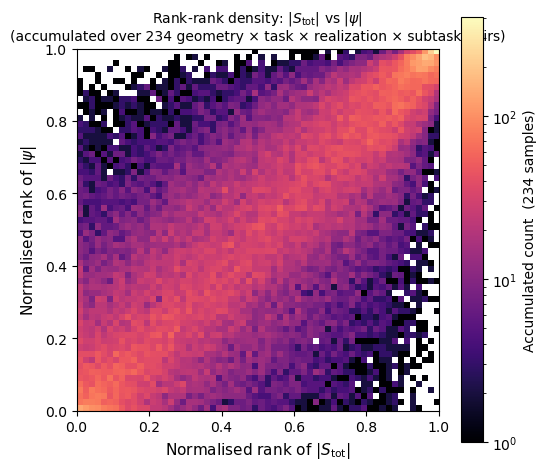

In [19]:
# ── 1. Rank-rank density heatmap ──────────────────────────────────────────────
heatmap_acc = np.zeros((N_BINS, N_BINS))
n_hm = 0

for gid, tid, rid, si, sd in flat_samples:
    abs_s   = np.abs(sd['s_tot'])
    abs_psi = np.abs(sd['psi'])
    E = len(abs_s)
    if E < 3:
        continue
    r_s   = (_rd(abs_s)   - 1.0) / E
    r_psi = (_rd(abs_psi) - 1.0) / E
    H, _, _ = np.histogram2d(r_s, r_psi, bins=N_BINS, range=[[0, 1], [0, 1]])
    heatmap_acc += H
    n_hm += 1

fig, ax = plt.subplots(figsize=(5.5, 5))
im = ax.imshow(
    heatmap_acc.T, origin='lower', aspect='equal',
    extent=[0, 1, 0, 1], cmap='magma',
    norm=mcolors.LogNorm(vmin=1, vmax=heatmap_acc.max()),
)
fig.colorbar(im, ax=ax, label=f'Accumulated count  ({n_hm} samples)')
ax.set_xlabel(r'Normalised rank of $|S_\mathrm{tot}|$', fontsize=11)
ax.set_ylabel(r'Normalised rank of $|\psi|$', fontsize=11)
ax.set_title(
    r'Rank-rank density: $|S_\mathrm{tot}|$ vs $|\psi|$'
    f'\n(accumulated over {n_hm} geometry × task × realization × subtask pairs)',
    fontsize=10,
)
plt.tight_layout()
plt.savefig(FIGURE_DIR / 'rank_rank_heatmap_allosteric_geom.svg', bbox_inches='tight')
plt.show()

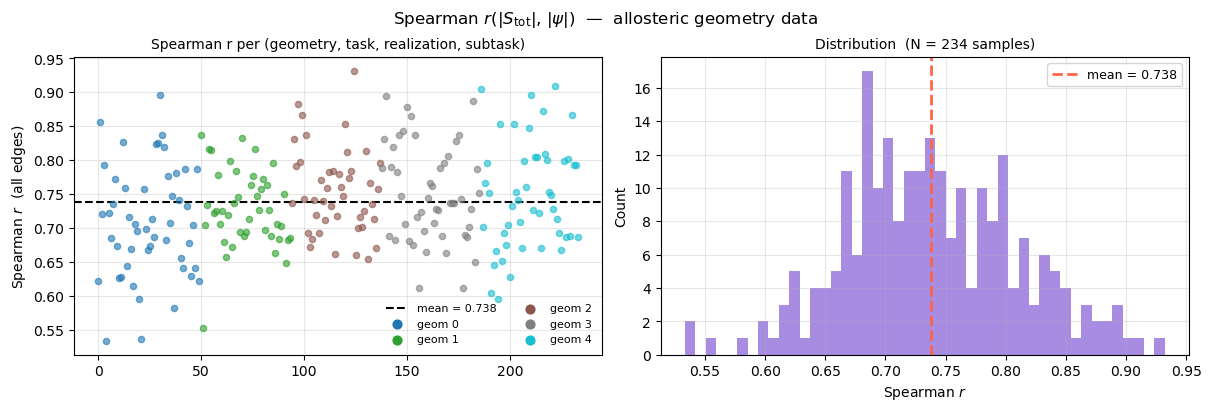

In [20]:
# ── 2. Spearman r distribution ────────────────────────────────────────────────
# Key: (gid, si) for grouping by geometry
r_vals   = []
r_labels = []
r_geoms  = []

for gid, tid, rid, si, sd in flat_samples:
    abs_s   = np.abs(sd['s_tot'])
    abs_psi = np.abs(sd['psi'])
    if len(abs_s) < 3 or np.std(abs_s) < 1e-12 or np.std(abs_psi) < 1e-12:
        continue
    r = _spearmanr(abs_s, abs_psi).statistic
    r_vals.append(r)
    r_labels.append(f'g{gid}t{tid}r{rid}s{si}')
    r_geoms.append(gid)

r_vals  = np.array(r_vals)
r_geoms = np.array(r_geoms)
mu      = np.nanmean(r_vals)

_geom_colors = plt.cm.tab10(np.linspace(0, 1, len(GEOMETRIES)))
_gcmap       = dict(zip(GEOMETRIES, _geom_colors))

fig, (ax, ax2) = plt.subplots(1, 2, figsize=(12, 4), constrained_layout=True)
for i, (r, g) in enumerate(zip(r_vals, r_geoms)):
    ax.scatter(i, r, color=_gcmap[g], s=20, alpha=0.6, zorder=3)
ax.axhline(mu, color='k', lw=1.5, ls='--', label=f'mean = {mu:.3f}')
ax.set_ylabel(r'Spearman $r$  (all edges)', fontsize=10)
ax.set_title('Spearman r per (geometry, task, realization, subtask)', fontsize=10)
ax.legend(fontsize=9); ax.grid(True, alpha=0.3)
# Per-geometry legend
for g in GEOMETRIES:
    ax.scatter([], [], color=_gcmap[g], label=f'geom {g}', s=40)
ax.legend(fontsize=8, ncol=2, frameon=False)

ax2.hist(r_vals, bins=max(5, len(r_vals) // 5), color='mediumpurple', alpha=0.8)
ax2.axvline(mu, color='tomato', lw=2, ls='--', label=f'mean = {mu:.3f}')
ax2.set_xlabel(r'Spearman $r$', fontsize=10)
ax2.set_ylabel('Count', fontsize=10)
ax2.set_title(f'Distribution  (N = {len(r_vals)} samples)', fontsize=10)
ax2.legend(fontsize=9); ax2.grid(True, alpha=0.3)
fig.suptitle(r'Spearman $r$($|S_\mathrm{tot}|$, $|\psi|$)  —  allosteric geometry data', fontsize=12)
plt.savefig(FIGURE_DIR / 'spearman_r_summary_allosteric_geom.svg', bbox_inches='tight')
plt.show()

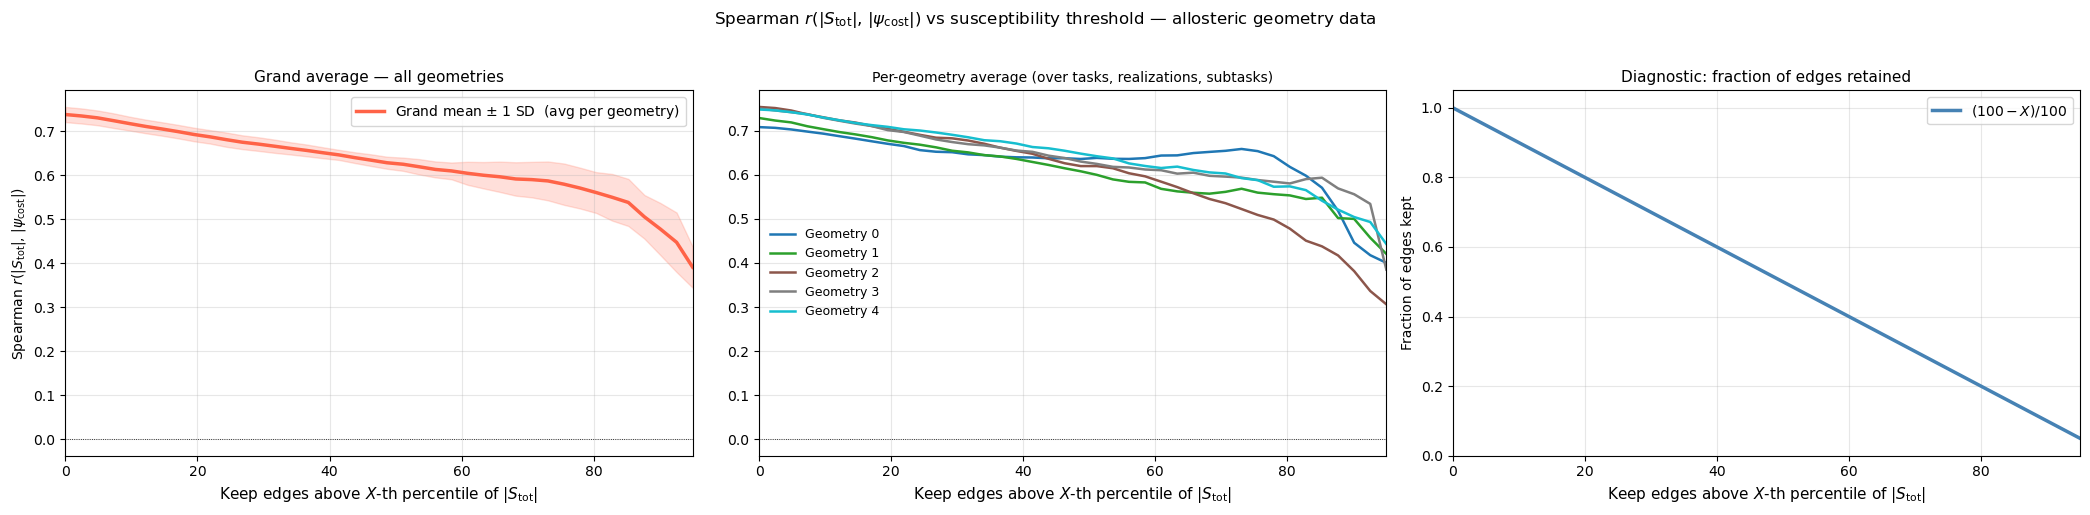

In [21]:
# ── 3. Spearman r vs susceptibility threshold ─────────────────────────────────
_EPS_SP = 1e-12

def _spearman_vs_threshold(abs_s, abs_psi, thresholds):
    out = np.full(len(thresholds), np.nan)
    for pi, thr in enumerate(thresholds):
        mask = abs_s >= np.percentile(abs_s, thr)
        if mask.sum() < 3:
            continue
        s_m, h_m = abs_s[mask], abs_psi[mask]
        if np.std(s_m) < _EPS_SP or np.std(h_m) < _EPS_SP:
            continue
        out[pi] = _spearmanr(s_m, h_m).statistic
    return out

_geom_curves = defaultdict(list)
_all_curves  = []

for gid, tid, rid, si, sd in flat_samples:
    abs_s   = np.abs(sd['s_tot'])
    abs_psi = np.abs(sd['psi'])
    curve   = _spearman_vs_threshold(abs_s, abs_psi, THRESHOLDS)
    _geom_curves[gid].append(curve)
    _all_curves.append(curve)

# Per-geometry average (over tasks, realizations, subtasks)
_geom_mean = {g: np.nanmean(curves, axis=0) for g, curves in _geom_curves.items()}
# Grand average (over geometries)
_grand_arr  = np.array(list(_geom_mean.values()))
_grand_mean = np.nanmean(_grand_arr, axis=0)
_grand_std  = np.nanstd(_grand_arr,  axis=0)

x      = THRESHOLDS
xlabel = r'Keep edges above $X$-th percentile of $|S_\mathrm{tot}|$'
ylabel = r'Spearman $r$($|S_\mathrm{tot}|$, $|\psi_\mathrm{cost}|$)'

fig, axes = plt.subplots(1, 3, figsize=(21, 5))

ax = axes[0]
ax.fill_between(x, _grand_mean - _grand_std, _grand_mean + _grand_std,
                alpha=0.2, color='tomato')
ax.plot(x, _grand_mean, color='tomato', lw=2.5,
        label=r'Grand mean $\pm$ 1 SD  (avg per geometry)')
ax.axhline(0, color='k', lw=0.6, ls=':')
ax.set_xlabel(xlabel, fontsize=11); ax.set_ylabel(ylabel, fontsize=10)
ax.set_title('Grand average — all geometries', fontsize=11)
ax.legend(fontsize=10); ax.grid(True, alpha=0.3); ax.set_xlim(x[0], x[-1])

ax2 = axes[1]
for g, curve in _geom_mean.items():
    ax2.plot(x, curve, color=_gcmap[g], lw=1.8, label=f'Geometry {g}')
ax2.axhline(0, color='k', lw=0.6, ls=':')
ax2.set_xlabel(xlabel, fontsize=11)
ax2.set_title('Per-geometry average (over tasks, realizations, subtasks)', fontsize=10)
ax2.legend(fontsize=9, frameon=False); ax2.grid(True, alpha=0.3); ax2.set_xlim(x[0], x[-1])

ax3 = axes[2]
frac_kept = (100.0 - x) / 100.0
ax3.plot(x, frac_kept, color='steelblue', lw=2.5, label='$(100 - X)/100$')
ax3.set_xlabel(xlabel, fontsize=11)
ax3.set_ylabel('Fraction of edges kept', fontsize=10)
ax3.set_title('Diagnostic: fraction of edges retained', fontsize=11)
ax3.set_xlim(x[0], x[-1]); ax3.set_ylim(0, 1.05)
ax3.legend(fontsize=10); ax3.grid(True, alpha=0.3)

fig.suptitle(
    r'Spearman $r$($|S_\mathrm{tot}|$, $|\psi_\mathrm{cost}|$) vs susceptibility threshold'
    ' — allosteric geometry data',
    fontsize=12, y=1.02,
)
plt.tight_layout()
plt.savefig(FIGURE_DIR / 'spearman_r_threshold_allosteric_geom.svg', bbox_inches='tight')
plt.show()

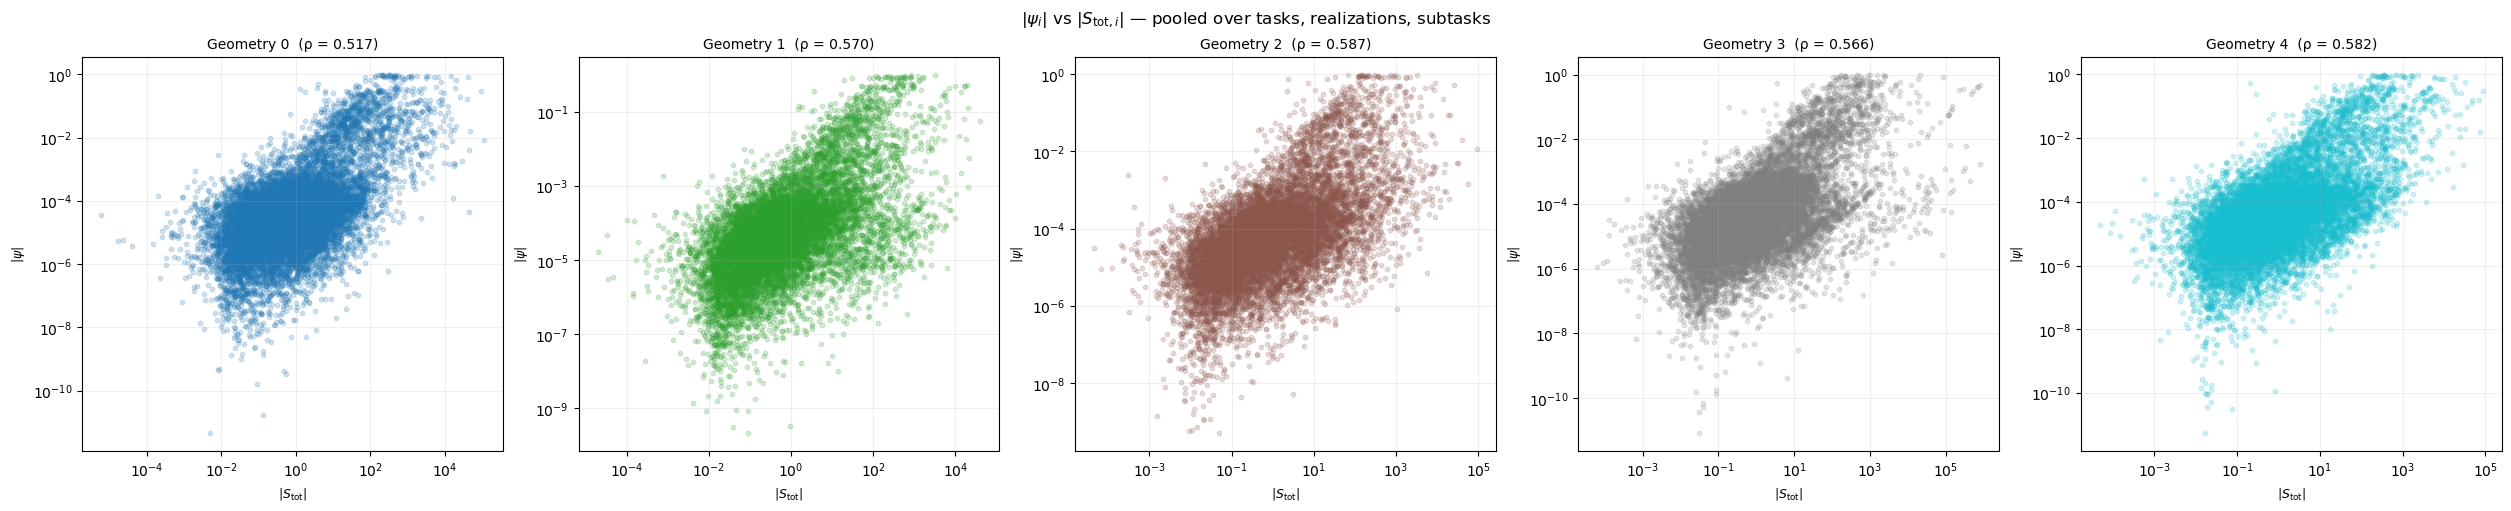

In [22]:
# ── 4. log-log scatter |ψ| vs |S_tot| (pooled per geometry) ──────────────────
n_geom = len(GEOMETRIES)
ncols  = min(5, n_geom)
nrows  = int(np.ceil(n_geom / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 5 * nrows), constrained_layout=True)
axes = np.array(axes).flat

_geom_s   = defaultdict(list)
_geom_psi = defaultdict(list)
for gid, tid, rid, si, sd in flat_samples:
    _geom_s[gid].append(np.abs(sd['s_tot']))
    _geom_psi[gid].append(np.abs(sd['psi']))

for ax, g in zip(axes, GEOMETRIES):
    xs = np.concatenate(_geom_s[g])
    ys = np.concatenate(_geom_psi[g])
    ax.scatter(xs, ys, s=10, alpha=0.2, rasterized=True, color=_gcmap[g])
    rho, _ = _spearmanr(xs, ys)
    ax.set_xscale('log'); ax.set_yscale('log')
    ax.set_xlabel(r'$|S_\mathrm{tot}|$', fontsize=9)
    ax.set_ylabel(r'$|\psi|$', fontsize=9)
    ax.set_title(f'Geometry {g}  (ρ = {rho:.3f})', fontsize=10)
    ax.grid(True, alpha=0.2, which='both')
for ax in list(axes)[n_geom:]:
    ax.set_visible(False)
fig.suptitle(r'$|\psi_i|$ vs $|S_{{\mathrm{{tot}},i}}|$ — pooled over tasks, realizations, subtasks', fontsize=12)
plt.savefig(FIGURE_DIR / 'psi_vs_stot_scatter_allosteric_geom.svg', bbox_inches='tight')
plt.show()

## Feature correlation heatmap (Analysis-9 style)

In [23]:
from scipy.stats import rankdata as _rankdata

FEAT_LABELS = [
    r'$|S_{\parallel}|$', r'$|S_{\perp}|$',
    r'$|S_{\mathrm{eq}}|$', r'$|S_{\mathrm{tot}}|$',
    'stiffness', 'strain', 'stress', r'$|\psi_{\mathrm{cost}}|$',
]
ROW_IDX    = [0, 1, 2, 3]   # susceptibility components
COL_IDX    = [4, 5, 6]      # stiffness, strain, stress
ROW_LABELS = [FEAT_LABELS[i] for i in ROW_IDX]
COL_LABELS = [FEAT_LABELS[i] for i in COL_IDX]

def _build_feature_stack(sd):
    """Stack 8 per-edge features, shape (8, n_edges)."""
    return np.stack([
        np.abs(sd['s_par']),
        np.abs(sd['s_perp']),
        np.abs(sd['s_eq']),
        np.abs(sd['s_tot']),
        sd['stiffness'],
        np.abs(sd['edge_strain']),
        np.abs(sd['edge_stress']),
        np.abs(sd['psi']),
    ], axis=0)  # (8, E)


def _pairwise_corr(feats):
    """Pearson and Spearman 8×8 matrices from (8, E) feature array."""
    P      = np.corrcoef(feats)
    ranked = np.apply_along_axis(_rankdata, 1, feats).astype(float)
    S      = np.corrcoef(ranked)
    return P, S


def _slice_4x3(mat):
    return np.asarray(mat, dtype=float)[np.ix_(ROW_IDX, COL_IDX)]


# Collect per-subtask and grand matrices
pearson_all  = defaultdict(list)   # geom → list of P matrices
spearman_all = defaultdict(list)
pearson_sub  = defaultdict(lambda: defaultdict(list))   # geom, si → list
spearman_sub = defaultdict(lambda: defaultdict(list))

for gid, tid, rid, si, sd in flat_samples:
    feats = _build_feature_stack(sd)
    P, S  = _pairwise_corr(feats)
    pearson_all[gid].append(P)
    spearman_all[gid].append(S)
    pearson_sub[gid][si].append(P)
    spearman_sub[gid][si].append(S)

print(f'Feature matrices computed for {sum(len(v) for v in pearson_all.values())} samples')

Feature matrices computed for 234 samples


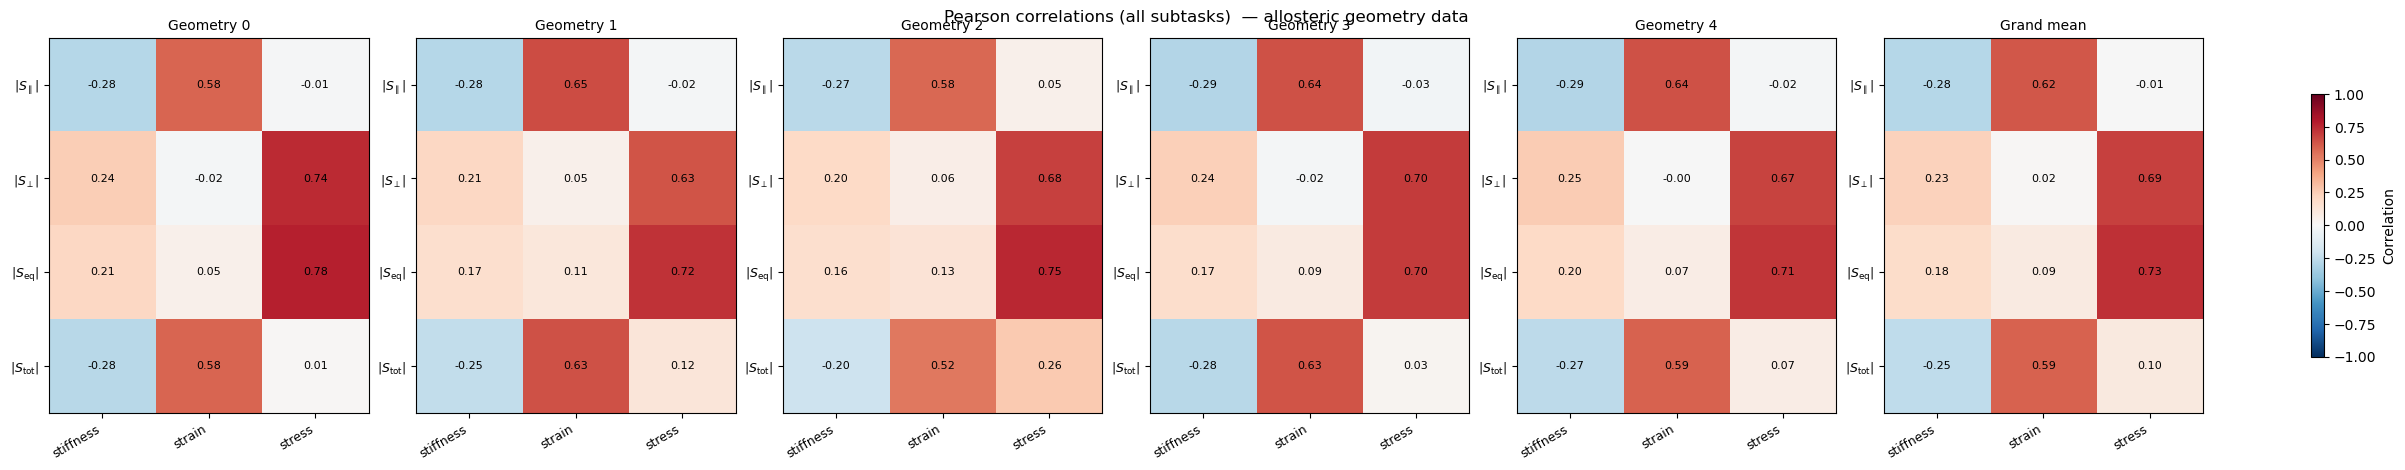

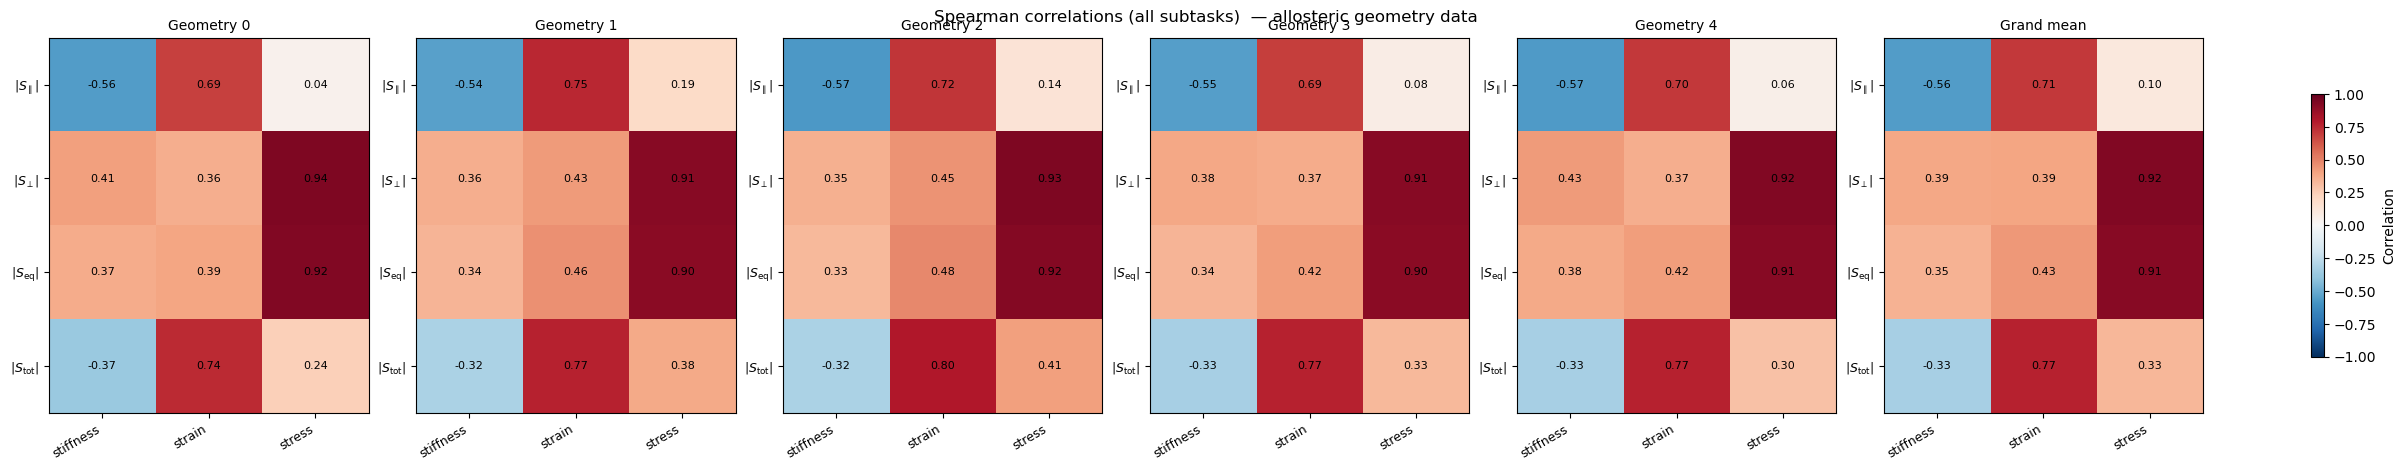

In [24]:
def _plot_heatmap_grid(matrices_dict, title, fname):
    """Plot 4×3 Pearson/Spearman submatrix for each geometry + grand mean."""
    geoms  = sorted(matrices_dict.keys())
    n_cols = len(geoms) + 1  # one column per geometry + grand average
    fig, axes = plt.subplots(1, n_cols, figsize=(4 * n_cols, 4.5), constrained_layout=True)

    grand_list = []
    for ax, g in zip(axes, geoms):
        mean_mat = np.nanmean(matrices_dict[g], axis=0)
        sliced   = _slice_4x3(mean_mat)
        grand_list.append(sliced)
        im = ax.imshow(sliced, vmin=-1, vmax=1, cmap='RdBu_r', aspect='auto')
        ax.set_xticks(range(3)); ax.set_xticklabels(COL_LABELS, rotation=30, ha='right', fontsize=9)
        ax.set_yticks(range(4)); ax.set_yticklabels(ROW_LABELS, fontsize=9)
        ax.set_title(f'Geometry {g}', fontsize=10)
        for ri in range(4):
            for ci in range(3):
                ax.text(ci, ri, f'{sliced[ri, ci]:.2f}', ha='center', va='center',
                        fontsize=8, color='k')
    # Grand mean
    grand_mean = np.nanmean(grand_list, axis=0)
    ax = axes[-1]
    im = ax.imshow(grand_mean, vmin=-1, vmax=1, cmap='RdBu_r', aspect='auto')
    ax.set_xticks(range(3)); ax.set_xticklabels(COL_LABELS, rotation=30, ha='right', fontsize=9)
    ax.set_yticks(range(4)); ax.set_yticklabels(ROW_LABELS, fontsize=9)
    ax.set_title('Grand mean', fontsize=10)
    for ri in range(4):
        for ci in range(3):
            ax.text(ci, ri, f'{grand_mean[ri, ci]:.2f}', ha='center', va='center',
                    fontsize=8, color='k')
    fig.colorbar(im, ax=list(axes), shrink=0.7, label='Correlation')
    fig.suptitle(title, fontsize=12, y=1.01)
    plt.savefig(FIGURE_DIR / fname, bbox_inches='tight')
    plt.show()


_plot_heatmap_grid(
    pearson_all,
    title='Pearson correlations (all subtasks)  — allosteric geometry data',
    fname='pearson_heatmap_allosteric_geom_all.svg',
)
_plot_heatmap_grid(
    spearman_all,
    title='Spearman correlations (all subtasks)  — allosteric geometry data',
    fname='spearman_heatmap_allosteric_geom_all.svg',
)

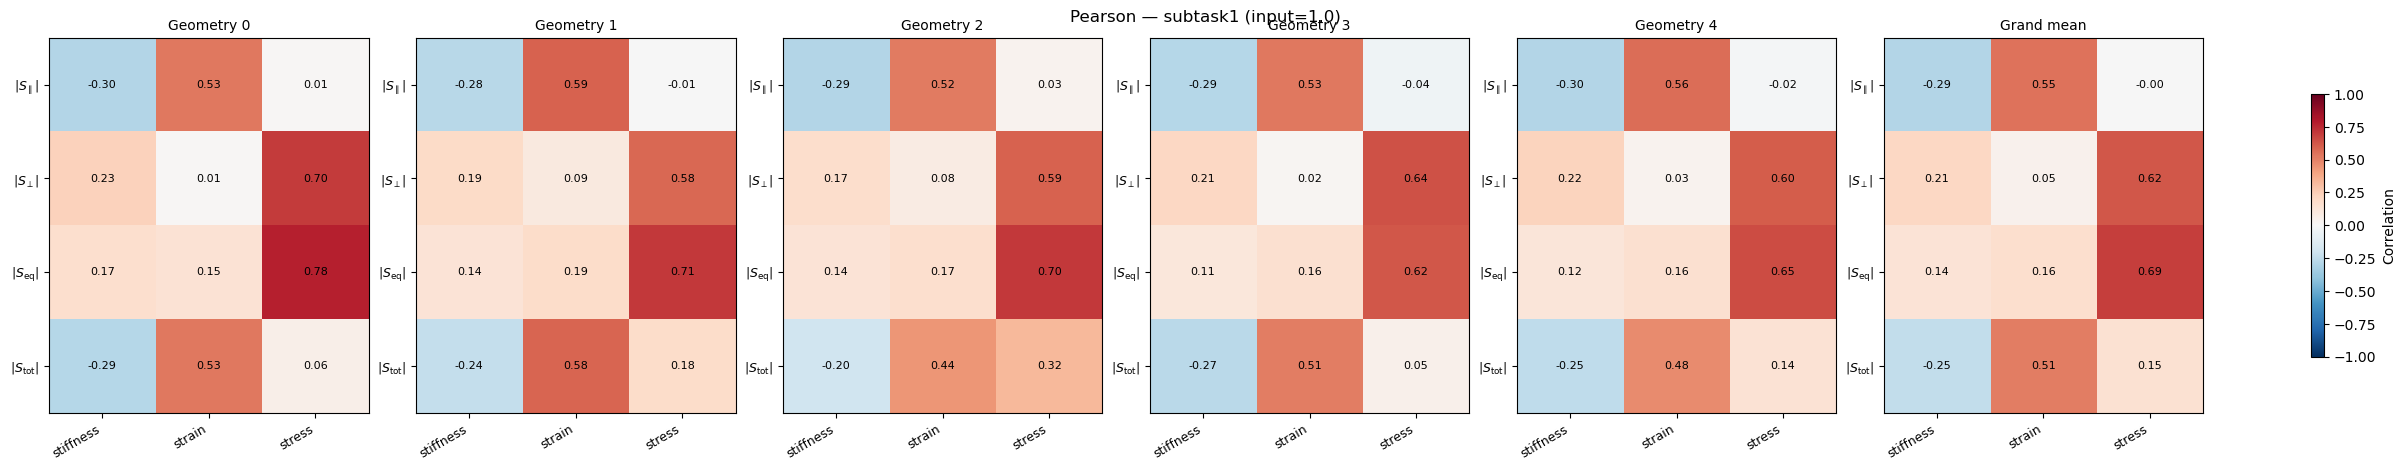

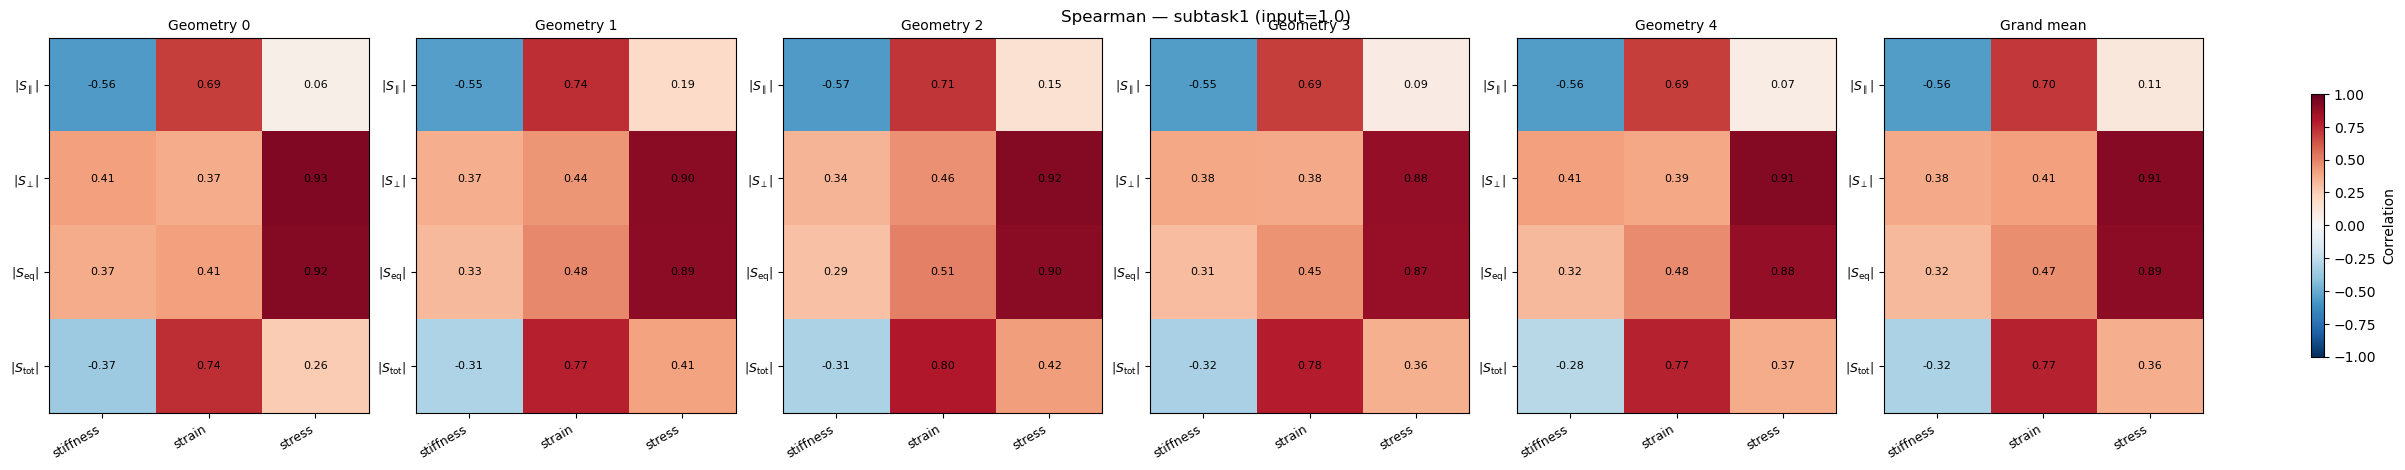

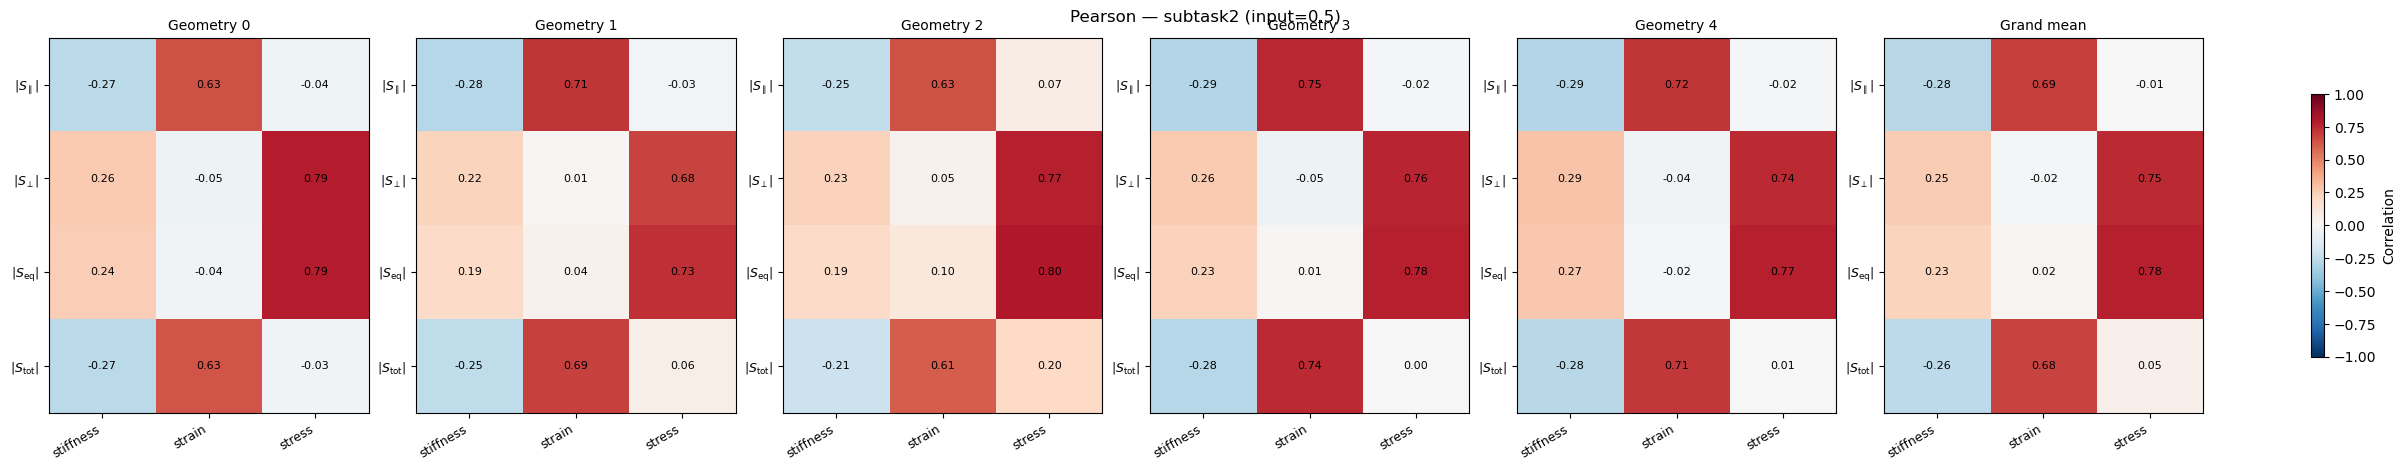

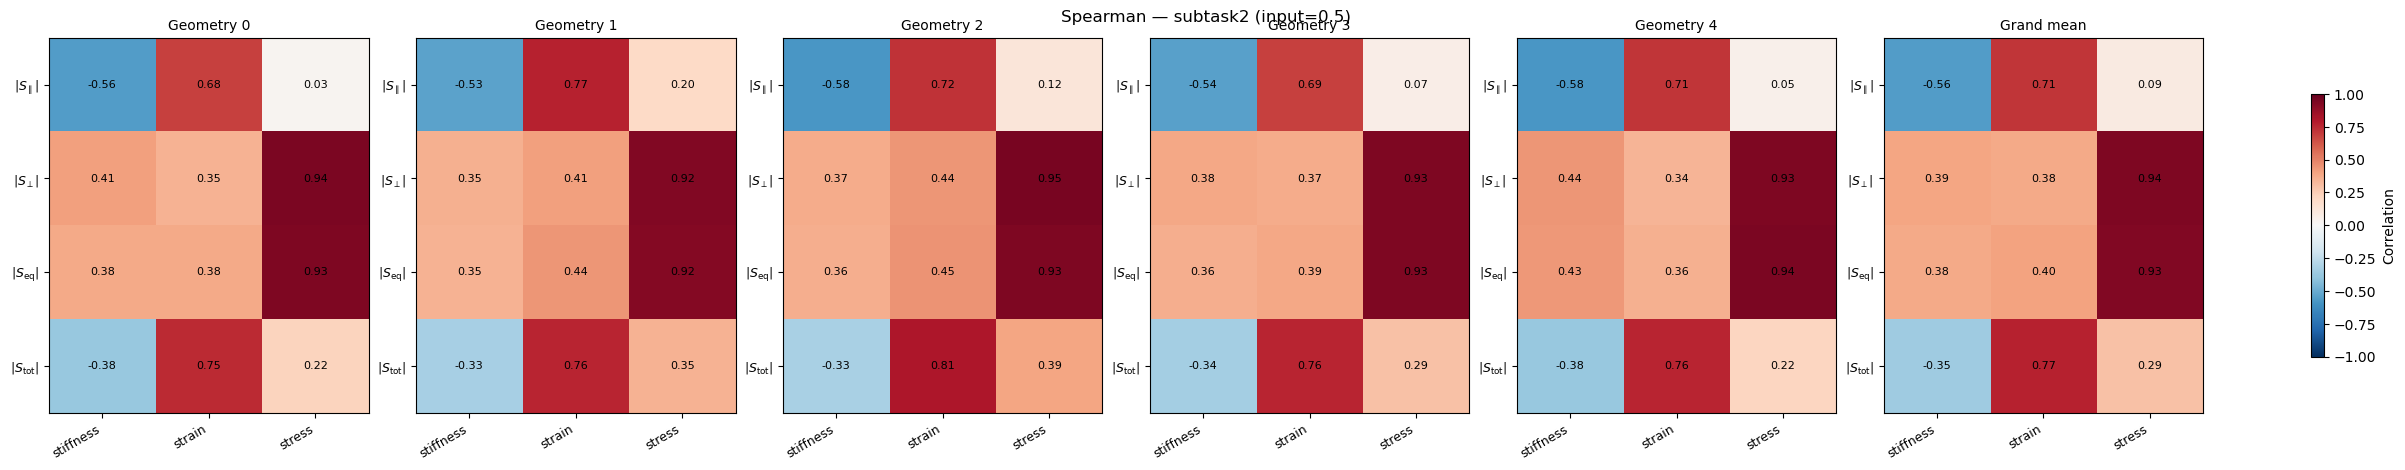

In [25]:
# Per-subtask heatmaps
for si_plot in range(2):
    strain_label = f'subtask{si_plot+1} (input={SUBTASK_STRAINS[si_plot]:.1f})'
    _plot_heatmap_grid(
        {g: pearson_sub[g][si_plot] for g in GEOMETRIES},
        title=f'Pearson — {strain_label}',
        fname=f'pearson_heatmap_allosteric_geom_si{si_plot+1}.svg',
    )
    _plot_heatmap_grid(
        {g: spearman_sub[g][si_plot] for g in GEOMETRIES},
        title=f'Spearman — {strain_label}',
        fname=f'spearman_heatmap_allosteric_geom_si{si_plot+1}.svg',
    )

## Averages — per geometry and grand

Per-geometry Spearman r mean ± std:
  Geometry 0: 0.7086 ± 0.0807
  Geometry 1: 0.7293 ± 0.0557
  Geometry 2: 0.7544 ± 0.0619
  Geometry 3: 0.7510 ± 0.0703
  Geometry 4: 0.7486 ± 0.0785
Grand (across geometries): 0.7384 ± 0.0173


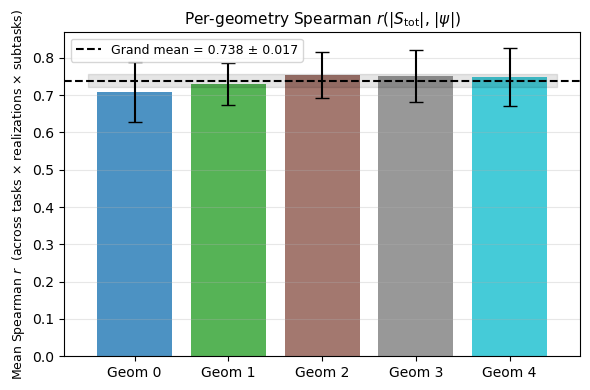

In [27]:
# ── Spearman r: per-geometry mean across tasks & realizations ─────────────────
geom_r_mean = {}
geom_r_std  = {}

for g in GEOMETRIES:
    rs = []
    for tid in range(N_TASKS):
        for rid in range(N_REALIZATIONS):
            try:
                d = all_results[g][tid][rid]
            except:
                continue
            
            if d is None:
                continue
            for sd in d['subtask_data']:
                abs_s   = np.abs(sd['s_tot'])
                abs_psi = np.abs(sd['psi'])
                if len(abs_s) < 3:
                    continue
                r = _spearmanr(abs_s, abs_psi).statistic
                if not np.isnan(r):
                    rs.append(r)
    geom_r_mean[g] = np.mean(rs) if rs else np.nan
    geom_r_std[g]  = np.std(rs)  if rs else np.nan

grand_r_mean = np.nanmean(list(geom_r_mean.values()))
grand_r_std  = np.nanstd( list(geom_r_mean.values()))

print('Per-geometry Spearman r mean ± std:')
for g in GEOMETRIES:
    print(f'  Geometry {g}: {geom_r_mean[g]:.4f} ± {geom_r_std[g]:.4f}')
print(f'Grand (across geometries): {grand_r_mean:.4f} ± {grand_r_std:.4f}')

fig, ax = plt.subplots(figsize=(6, 4))
xs = list(GEOMETRIES)
ys = [geom_r_mean[g] for g in xs]
es = [geom_r_std[g]  for g in xs]
ax.bar(xs, ys, yerr=es, color=[_gcmap[g] for g in xs], alpha=0.8, capsize=5)
ax.axhline(grand_r_mean, color='k', lw=1.5, ls='--',
           label=f'Grand mean = {grand_r_mean:.3f} ± {grand_r_std:.3f}')
ax.fill_between([-0.5, len(xs) - 0.5],
                grand_r_mean - grand_r_std, grand_r_mean + grand_r_std,
                alpha=0.1, color='k')
ax.set_xticks(xs); ax.set_xticklabels([f'Geom {g}' for g in xs])
ax.set_ylabel(r'Mean Spearman $r$  (across tasks × realizations × subtasks)', fontsize=9)
ax.set_title(r'Per-geometry Spearman $r$($|S_\mathrm{tot}|$, $|\psi|$)', fontsize=11)
ax.legend(fontsize=9); ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig(FIGURE_DIR / 'per_geometry_spearman_r_allosteric.svg', bbox_inches='tight')
plt.show()

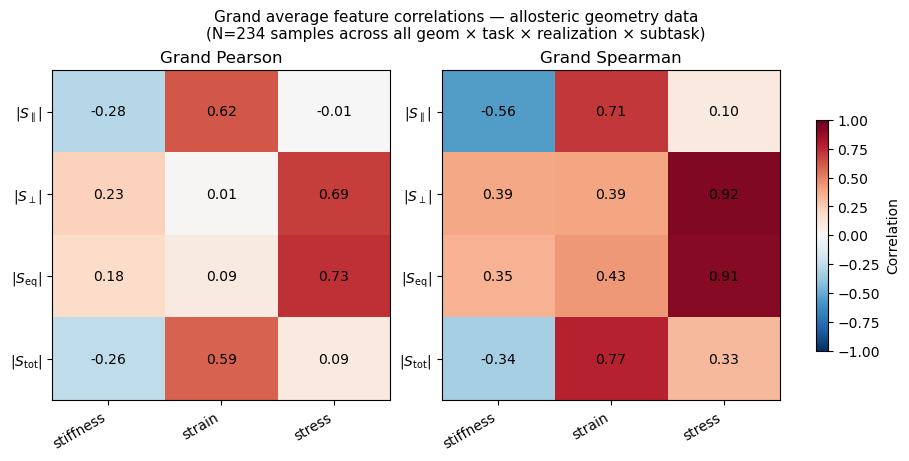


Grand Pearson (4×3):
[[-0.28390992  0.61727517 -0.00680044]
 [ 0.22994058  0.01347232  0.68751492]
 [ 0.18231865  0.0907703   0.73436756]
 [-0.25534266  0.59212445  0.09498983]]

Grand Spearman (4×3):
[[-0.55881175  0.70867156  0.09933234]
 [ 0.38808276  0.39276374  0.92241189]
 [ 0.35101328  0.43202078  0.91110194]
 [-0.33507537  0.77012291  0.32551788]]


In [28]:
# ── Grand average feature correlation matrices ────────────────────────────────
all_pearson_flat  = [P for g in GEOMETRIES for P in pearson_all[g]]
all_spearman_flat = [S for g in GEOMETRIES for S in spearman_all[g]]

grand_pearson  = _slice_4x3(np.nanmean(all_pearson_flat,  axis=0))
grand_spearman = _slice_4x3(np.nanmean(all_spearman_flat, axis=0))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(9, 4.5), constrained_layout=True)
for ax, mat, title in [
    (ax1, grand_pearson,  'Grand Pearson'),
    (ax2, grand_spearman, 'Grand Spearman'),
]:
    im = ax.imshow(mat, vmin=-1, vmax=1, cmap='RdBu_r', aspect='auto')
    ax.set_xticks(range(3)); ax.set_xticklabels(COL_LABELS, rotation=30, ha='right', fontsize=10)
    ax.set_yticks(range(4)); ax.set_yticklabels(ROW_LABELS, fontsize=10)
    ax.set_title(title, fontsize=12)
    for ri in range(4):
        for ci in range(3):
            ax.text(ci, ri, f'{mat[ri, ci]:.2f}', ha='center', va='center', fontsize=10, color='k')
fig.colorbar(im, ax=[ax1, ax2], shrink=0.7, label='Correlation')
fig.suptitle(
    'Grand average feature correlations — allosteric geometry data\n'
    f'(N={len(all_pearson_flat)} samples across all geom × task × realization × subtask)',
    fontsize=11,
)
plt.savefig(FIGURE_DIR / 'grand_feature_corr_allosteric_geom.svg', bbox_inches='tight')
plt.show()

print('\nGrand Pearson (4×3):')
print(grand_pearson)
print('\nGrand Spearman (4×3):')
print(grand_spearman)

In [29]:
# ── Summary table ─────────────────────────────────────────────────────────────
print('='*65)
print('SUMMARY')
print('='*65)
n_total  = sum(1 for g in GEOMETRIES for t in range(N_TASKS) for r in range(N_REALIZATIONS))
n_ok     = len(flat_samples) // 2  # divide by 2 subtasks
print(f'Networks loaded / total: {n_ok}/{n_total}')
print(f'(geometry, task, realization, subtask) samples: {len(flat_samples)}')
print(f'Grand Spearman r mean ± SD: {grand_r_mean:.4f} ± {grand_r_std:.4f}')
print()
print('Per-geometry r:')
for g in GEOMETRIES:
    print(f'  Geometry {g}: {geom_r_mean[g]:.4f} ± {geom_r_std[g]:.4f}')

SUMMARY
Networks loaded / total: 117/125
(geometry, task, realization, subtask) samples: 234
Grand Spearman r mean ± SD: 0.7384 ± 0.0173

Per-geometry r:
  Geometry 0: 0.7086 ± 0.0807
  Geometry 1: 0.7293 ± 0.0557
  Geometry 2: 0.7544 ± 0.0619
  Geometry 3: 0.7510 ± 0.0703
  Geometry 4: 0.7486 ± 0.0785
